# DSCI 521 Final Project: Data Import and Initial EDA Notebook

In this notebook we will be acessing the data from **pklmart's Competitive Pickleball Extracts** from Kaggle. This dataset provides data related to over 900 pickleball matches of varying skill levels.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

## Data Import

In this section we will be importing the various datsets present, and will take a look at what data is available for this project.


#### Game Data

Below we will be importing the game data that gives us an overview of general game information, letting us know what

In [5]:
game_df = pd.read_csv("/content/drive/MyDrive/DSCI 521 Final Project (Pickleball Analytics)/data/raw/game.csv")
game_df.head()

In [ ]:
#game_df.info()

In [6]:
rally_df = pd.read_csv("/content/drive/MyDrive/DSCI 521 Final Project (Pickleball Analytics)/data/raw/rally.csv")
#rally_df.head()

In [16]:
rally_df.head()

,rally_id,game_id,match_id,rally_nbr,w_team_id,srv_team_id,srv_player_id,rtrn_team_id,rtrn_player_id,ts_player_id,...,ending_type,ending_player_id,srv_switch_ind,rtrn_switch_ind,srv_team_flipped_ind,rtrn_team_flipped_ind,srv_team_rs_player_id,srv_team_ls_player_id,rtrn_team_rs_player_id,rtrn_team_ls_player_id
0,R8968,G208,M113,6,T152,T152,P202,T155,P70,P202,...,Other,NaN,Y,N,N,N,P203,P202,P70,P205
1,R8963,G208,M113,1,T155,T152,P202,T155,P70,NaN,...,Error,P203,Y,N,N,N,P203,P202,P70,P205
2,R8964,G208,M113,2,T152,T155,P70,T152,P202,P205,...,Error,P205,N,Y,N,N,P70,P205,P203,P202
3,R8965,G208,M113,3,T155,T155,P205,T152,P203,P205,...,Error,P203,N,Y,N,N,P70,P205,P203,P202
4,R8966,G208,M113,4,T155,T155,P205,T152,P202,P70,...,Winner,P205,Y,Y,Y,N,P70,P205,P203,P202


In [17]:
rally_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40702 entries, 0 to 40701
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   rally_id                40702 non-null  object 
 1   game_id                 40702 non-null  object 
 2   match_id                40702 non-null  object 
 3   rally_nbr               40702 non-null  int64  
 4   w_team_id               40323 non-null  object 
 5   srv_team_id             40702 non-null  object 
 6   srv_player_id           40323 non-null  object 
 7   rtrn_team_id            40702 non-null  object 
 8   rtrn_player_id          40323 non-null  object 
 9   ts_player_id            32422 non-null  object 
 10  ts_type                 37420 non-null  object 
 11  to_ind                  40702 non-null  object 
 12  to_team_id              379 non-null    object 
 13  rally_len               40193 non-null  float64
 14  ending_type             40319 non-null

In [18]:
shot_df = pd.read_csv("/content/drive/MyDrive/DSCI 521 Final Project (Pickleball Analytics)/data/raw/shot.csv")
#shot_df.head()

,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
0,S213113,R26079,2,R,P582,18.35,23.70,18.64,21.59
1,S237646,R29288,3,tsDrv,P670,13.68,21.77,11.84,0.00
2,S213112,R26079,1,SE,P197,13.40,22.32,18.35,23.70
3,S213152,R26086,1,SE,P488,5.60,22.97,3.29,24.25
4,S213210,R26092,2,R,P488,5.50,20.58,9.81,12.03


To modify the shot location data so that it can all be plotted on the same graph, the following transformations can me made to the next_loc columns:

As both loc and next_loc are taken from the perspective of the player, to be able to grahically represent the shot direction as well as the relative location of each shot we will:

1. Subtract the values of next_loc_x from 20 (The width of the court to have the opposite reference point of the shot.
2. Multiply next_loc_y by -1 to reverese the positions of the ball pertaining to the length of the data frame

In [8]:
shot_df_copy = shot_df.copy()

# Changing the orientation of next_loc values for the purpose of plotting the values which will help with vector representation of shots
shot_df_copy['next_loc_x'] = 20 - shot_df_copy['next_loc_x']
shot_df_copy['next_loc_y'] = shot_df_copy['next_loc_y'] * -1

shot_df_copy.head()

,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
0,S213113,R26079,2,R,P582,18.35,23.70,1.36,-21.59
1,S237646,R29288,3,tsDrv,P670,13.68,21.77,8.16,-0.00
2,S213112,R26079,1,SE,P197,13.40,22.32,1.65,-23.70
3,S213152,R26086,1,SE,P488,5.60,22.97,16.71,-24.25
4,S213210,R26092,2,R,P488,5.50,20.58,10.19,-12.03


In [9]:
shot_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304649 entries, 0 to 304648
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   shot_id     304649 non-null  object 
 1   rally_id    304649 non-null  object 
 2   shot_nbr    304649 non-null  int64  
 3   shot_type   304637 non-null  object 
 4   player_id   304573 non-null  object 
 5   loc_x       304649 non-null  float64
 6   loc_y       304565 non-null  float64
 7   next_loc_x  292402 non-null  float64
 8   next_loc_y  292402 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 20.9+ MB


In [10]:
ball_typ_df = pd.read_csv("/content/drive/MyDrive/DSCI 521 Final Project (Pickleball Analytics)/data/raw/ball_type_ref.csv")
ball_typ_df.head()

,ball_type,ball_type_desc
0,D40,Dura Fast 40
1,FX40,Franklin X-40
2,U,Unknown
3,O,Other
4,CORE,CORE Pickleball Outdoor


In [11]:
player_df = pd.read_csv("/content/drive/MyDrive/DSCI 521 Final Project (Pickleball Analytics)/data/raw/player.csv")
player_df.head()

Loop through player ID'S to eventually cross reference with the skill level by connecting the player to their repective team, and be able to match their level with the level of match that they are playing. This could also be used to see if their is a miss match in the game level.

In [12]:
player_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   player_id                923 non-null    object 
 1   gender                   921 non-null    object 
 2   dom_hand                 921 non-null    object 
 3   doubles_dupr             369 non-null    float64
 4   doublesreliabilityscore  372 non-null    float64
dtypes: float64(2), object(3)
memory usage: 36.2+ KB


In [14]:
shot_typ_df = pd.read_csv("/content/drive/MyDrive/DSCI 521 Final Project (Pickleball Analytics)/data/raw/shot_type_ref.csv")
shot_typ_df.head()

,shot_type,shot_type_desc,shot_type_desc_full
0,O,Other,NaN
1,U,Unknown,NaN
2,SE,Serve,The first shot of a rally; must bounce; must l...
3,R,Return,The second shot of a rally; must bounce. Retur...
4,tsDrp,3rd Shot Drop,The third shot of a rally; player attempts to ...


In [15]:
team_df = pd.read_csv("/content/drive/MyDrive/DSCI 521 Final Project (Pickleball Analytics)/data/raw/team.csv")
team_df.head()

,team_id,player_id,player_seq_nbr
0,T3,P5,1
1,T3,P2,2
2,T5,P8,1
3,T5,P9,2
4,T7,P12,1


## Initial Exploratory Data Analysis

### Unvariate Analysis

To begin we will start by looking at vanivartiate analysis

In [ ]:
game_df['skill_lvl'].value_counts()

,count
skill_lvl,
4.0,328
Pro,196
5.0,163
4.5,131
3.5,65
5.5,22
3.0,18
2.5,8
Senior Pro,4


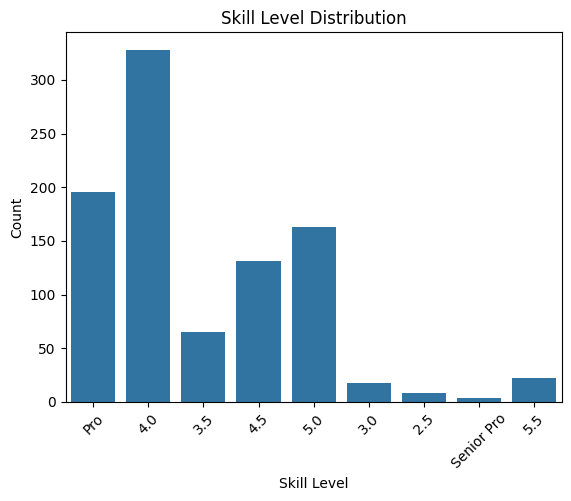

In [ ]:
sns.countplot(data=game_df, x='skill_lvl')
plt.xticks(rotation=45)
plt.xlabel('Skill Level')
plt.ylabel('Count')
plt.title('Skill Level Distribution')
plt.show()

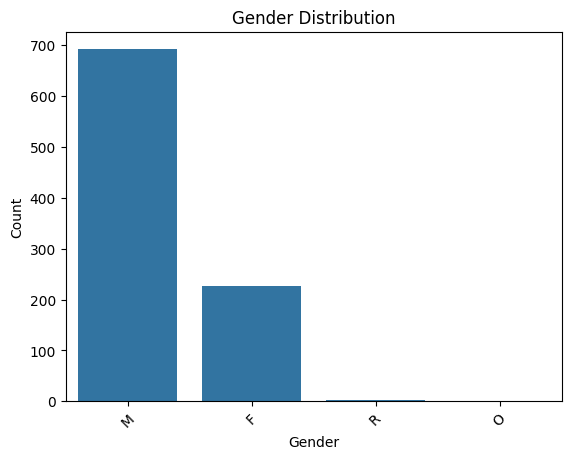

In [ ]:
sns.countplot(data=player_df, x='gender')
plt.xticks(rotation=45)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution')
plt.show()

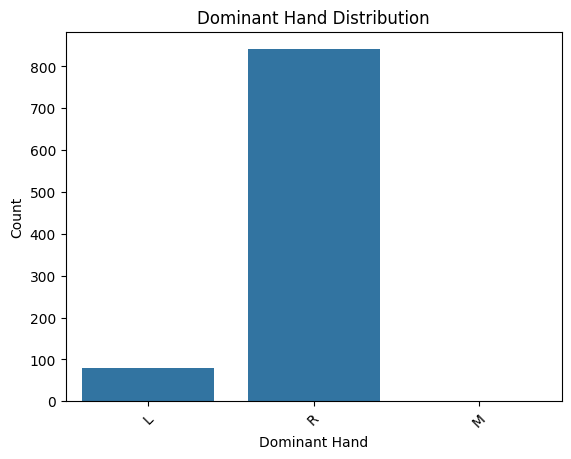

In [ ]:
sns.countplot(data=player_df, x='dom_hand')
plt.xticks(rotation=45)
plt.xlabel('Dominant Hand')
plt.ylabel('Count')
plt.title('Dominant Hand Distribution')
plt.show()

In [ ]:
game_df['game_nbr'].value_counts()

,count
game_nbr,
1,761
2,108
3,54
4,10
5,1
6,1


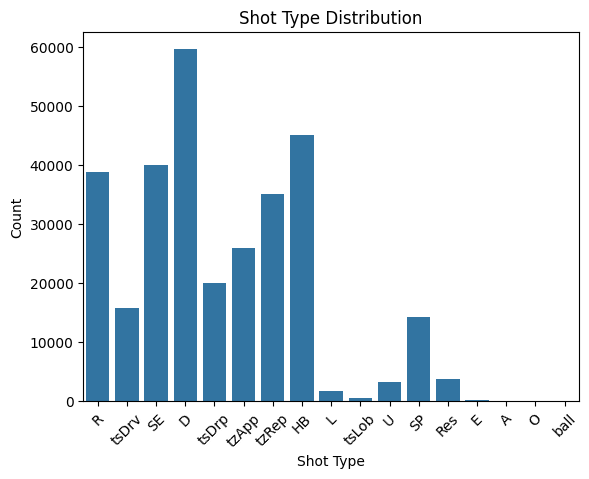

In [ ]:
# Shot type distribution throughout the dataset

sns.countplot(data=shot_df, x='shot_type')
plt.xticks(rotation=45)
plt.xlabel('Shot Type')
plt.ylabel('Count')
plt.title('Shot Type Distribution')
plt.show()

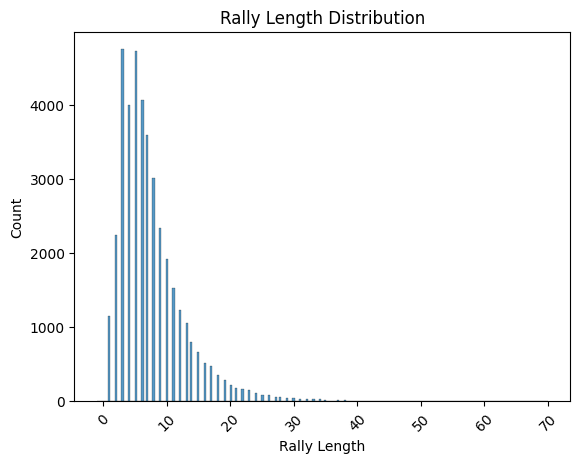

In [ ]:
# Histogram of rally length distribution


sns.histplot(data=rally_df, x='rally_len')
plt.xticks(rotation=45)
plt.xlabel('Rally Length')
plt.ylabel('Count')
plt.title('Rally Length Distribution')
plt.show()

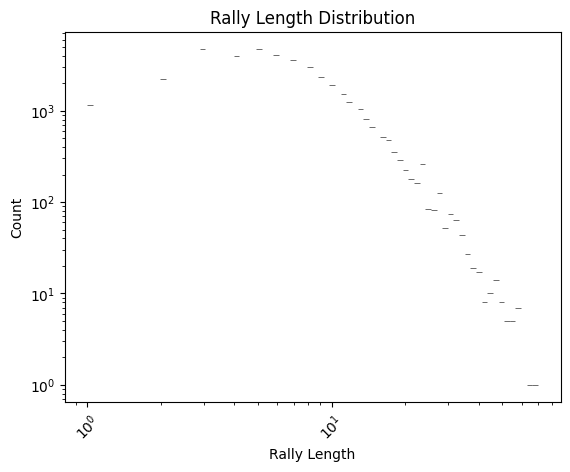

In [ ]:
sns.histplot(data=rally_df, x='rally_len', log_scale=(10,10))
plt.xticks(rotation=45)
plt.xlabel('Rally Length')
plt.ylabel('Count')
plt.title('Rally Length Distribution')
plt.show()

In [ ]:
# Rally Ending Type Distribution over the whole Dataset

rally_df['ending_type'].value_counts()

,count
ending_type,
Error,20395
Winner,12814
Unforced Error,4081
Other,3029


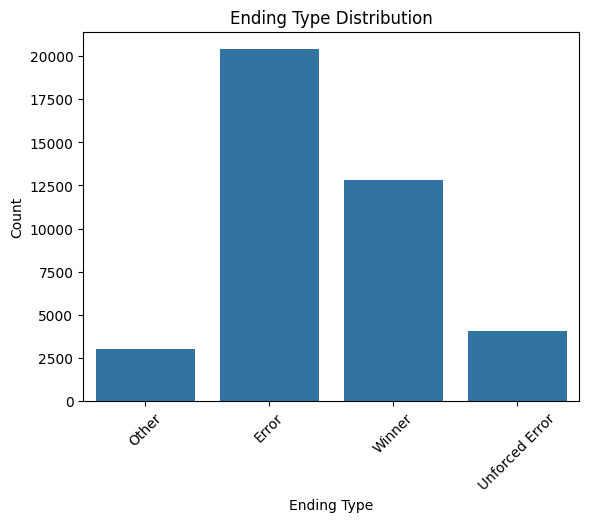

In [ ]:
sns.countplot(data=rally_df, x='ending_type' )
plt.xticks(rotation=45)
plt.xlabel('Ending Type')
plt.ylabel('Count')
plt.title('Ending Type Distribution')
plt.show()

Want to build another plot here where we would like to see what the shot type distribution is with reference to the rally ending.

In [ ]:
# I want to graphically draw a pickleball court
def draw_pickleball_court():
    fig, ax = plt.subplots(figsize=(8, 12))

    # Dimensions based on your request
    width = 20
    half_length = 22
    kitchen_offset = 7 # Standard kitchen is 7ft from net

    # 1. Draw the Main Court Boundary
    # Rectangle( (x_start, y_start), width, height )
    court = patches.Rectangle((0, -half_length), width, half_length * 2,
                              linewidth=2, edgecolor='black', facecolor='none')
    ax.add_patch(court)

    # 2. Draw the Net (Center line at y=0)
    ax.plot([0, width], [0, 0], color='black', linewidth=3, label='Net')

    # 3. Draw Non-Volley Zone (Kitchen) lines
    ax.plot([0, width], [kitchen_offset, kitchen_offset], color='black', linewidth=2)
    ax.plot([0, width], [-kitchen_offset, -kitchen_offset], color='black', linewidth=2)

    # 4. Draw Center lines (splitting the service courts)
    # From top kitchen line to top baseline
    ax.plot([width/2, width/2], [kitchen_offset, half_length], color='black', linewidth=2)
    # From bottom kitchen line to bottom baseline
    ax.plot([width/2, width/2], [-kitchen_offset, -half_length], color='black', linewidth=2)

    # 5. Optional: Highlight the Kitchen Area
    kitchen_top = patches.Rectangle((0, 0), width, kitchen_offset, color='gray', alpha=0.1)
    kitchen_bottom = patches.Rectangle((0, -kitchen_offset), width, kitchen_offset, color='gray', alpha=0.1)
    ax.add_patch(kitchen_top)
    ax.add_patch(kitchen_bottom)

    # Example: Plotting shot data
    # Let's say you have a list of (x, y) coordinates
    shots_x = [5, 15, 10, 2]
    shots_y = [15, -18, 5, -5]
    ax.scatter(shots_x, shots_y, color='red', s=100, label='Shots', zorder=5)

    # Formatting
    ax.set_xlim(-2, width + 2)
    ax.set_ylim(-half_length - 2, half_length + 2)
    ax.set_aspect('equal') # Crucial to keep the court proportions correct
    ax.set_title("Pickleball Shot Map")
    ax.set_xlabel("Width (0 to 20)")
    ax.set_ylabel("Length (-22 to 22)")
    ax.legend()

    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

draw_pickleball_court()

### Feature Engineering

For our data to be better utillized within a machine learning model, we would need to find a way to make the shots have some form or sequence, llowing us to have a better idea of shot choices.



In [ ]:
# First we would like to have a solid example of our process so lets make an example scenario of

rally_len_dict = {}
for index, row in rally_df.iterrows():
  rally_len_dict[row['rally_id']] = row['rally_len']


In [ ]:
print(rally_len_dict)

In [ ]:
test_rally = shot_df[shot_df['rally_id'] == 'R8989']
test_rally.head()

,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
30960,S83169,R8989,18,D,P70,3.47,7.17,4.68,4.50
30961,S83170,R8989,19,D,P203,4.68,4.50,4.67,7.35
32715,S83157,R8989,6,D,P70,5.41,7.81,5.49,8.63
32716,S83158,R8989,7,D,P203,5.49,8.63,3.57,5.51
32750,S83159,R8989,8,D,P70,3.57,5.51,1.73,7.07


In [ ]:
test_rally = shot_df[shot_df['rally_id'] == 'R8989']
sorted_test_rally = test_rally.sort_values(by = "shot_nbr").reset_index(drop=True)

In [ ]:
sorted_test_rally.head()

,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
0,S83152,R8989,1,SE,P203,11.74,22.32,13.77,21.04
1,S83153,R8989,2,R,P70,13.77,21.04,4.58,17.18
2,S83154,R8989,3,tsDrp,P203,4.58,17.18,1.74,9.09
3,S83155,R8989,4,D,P70,1.74,9.09,15.60,7.99
4,S83156,R8989,5,D,P202,15.60,7.99,5.41,7.81


In [ ]:
sorted_test_rally.tail()

,shot_id,rally_id,shot_nbr,shot_type,player_id,loc_x,loc_y,next_loc_x,next_loc_y
18,S83170,R8989,19,D,P203,4.68,4.50,4.67,7.35
19,S83171,R8989,20,SP,P70,4.67,7.35,3.67,7.35
20,S83172,R8989,21,HB,P203,3.67,7.35,5.95,10.10
21,S83173,R8989,22,HB,P70,5.95,10.10,7.98,18.83
22,S83174,R8989,23,HB,P203,7.98,18.83,NaN,NaN


In [ ]:
len(sorted_test_rally)

In [ ]:
def reference_change(df):
  new_df = df.copy()
  indices = list(new_df.index)
  for i in range(len(new_df)):
      if i % 2 == 0:
          new_df.loc[indices[i],'loc_x'] = 20 - new_df.loc[indices[i],'loc_x']
          new_df.loc[indices[i],'loc_y'] = -new_df.loc[indices[i],'loc_y']
      else:
          new_df.loc[indices[i],'next_loc_x'] = 20 - new_df.loc[indices[i],'next_loc_x']
          new_df.loc[indices[i],'next_loc_y'] = -new_df.loc[indices[i],'next_loc_y']

  return new_df

In [ ]:
play_data = reference_change(sorted_test_rally)

play_data.head()

In [ ]:
# I want to graphically draw a pickleball court
def draw_pickleball_court(df):

    fig, ax = plt.subplots(figsize=(8, 12))

    # Dimensions based on your request
    width = 20
    half_length = 22
    kitchen_offset = 7 # Standard kitchen is 7ft from net

    # 1. Draw the Main Court Boundary
    # Rectangle( (x_start, y_start), width, height )
    court = patches.Rectangle((0, -half_length), width, half_length * 2,
                              linewidth=2, edgecolor='black', facecolor='none')
    ax.add_patch(court)

    # 2. Draw the Net (Center line at y=0)
    ax.plot([0, width], [0, 0], color='black', linewidth=3, label='Net')

    # 3. Draw Non-Volley Zone (Kitchen) lines
    ax.plot([0, width], [kitchen_offset, kitchen_offset], color='black', linewidth=2)
    ax.plot([0, width], [-kitchen_offset, -kitchen_offset], color='black', linewidth=2)

    # 4. Draw Center lines (splitting the service courts)
    # From top kitchen line to top baseline
    ax.plot([width/2, width/2], [kitchen_offset, half_length], color='black', linewidth=2)
    # From bottom kitchen line to bottom baseline
    ax.plot([width/2, width/2], [-kitchen_offset, -half_length], color='black', linewidth=2)

    # 5. Optional: Highlight the Kitchen Area
    kitchen_top = patches.Rectangle((0, 0), width, kitchen_offset, color='gray', alpha=0.1)
    kitchen_bottom = patches.Rectangle((0, -kitchen_offset), width, kitchen_offset, color='gray', alpha=0.1)
    ax.add_patch(kitchen_top)
    ax.add_patch(kitchen_bottom)

    # Example: Plotting shot data
    # Let's say you have a list of (x, y) coordinates
    # shots_x = [5, 15, 10, 2]
    # shots_y = [15, -18, 5, -5]
    shots_x = df['loc_x'][:5]
    shots_y = df['loc_y'][:5]
    ax.scatter(shots_x, shots_y, color='red', s=100, label='Shots', zorder=2)

    # Formatting
    ax.set_xlim(-2, width + 2)
    ax.set_ylim(-half_length - 2, half_length + 2)
    ax.set_aspect('equal') # Crucial to keep the court proportions correct
    ax.set_title("Pickleball Shot Map")
    ax.set_xlabel("Width (0 to 20)")
    ax.set_ylabel("Length (-22 to 22)")
    ax.legend()

    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

draw_pickleball_court(play_data)

In [ ]:
# I want to graphically draw a pickleball court
def draw_pickleball_court(df):
    fig, ax = plt.subplots(figsize=(8, 12))

    # Dimensions based on your request
    width = 20
    half_length = 22
    kitchen_offset = 7 # Standard kitchen is 7ft from net

    # 1. Draw the Main Court Boundary
    # Rectangle( (x_start, y_start), width, height )
    court = patches.Rectangle((0, -half_length), width, half_length * 2,
                              linewidth=2, edgecolor='black', facecolor='none')
    ax.add_patch(court)

    # 2. Draw the Net (Center line at y=0)
    ax.plot([0, width], [0, 0], color='black', linewidth=3, label='Net')

    # 3. Draw Non-Volley Zone (Kitchen) lines
    ax.plot([0, width], [kitchen_offset, kitchen_offset], color='black', linewidth=2)
    ax.plot([0, width], [-kitchen_offset, -kitchen_offset], color='black', linewidth=2)

    # 4. Draw Center lines (splitting the service courts)
    # From top kitchen line to top baseline
    ax.plot([width/2, width/2], [kitchen_offset, half_length], color='black', linewidth=2)
    # From bottom kitchen line to bottom baseline
    ax.plot([width/2, width/2], [-kitchen_offset, -half_length], color='black', linewidth=2)

    # 5. Optional: Highlight the Kitchen Area
    kitchen_top = patches.Rectangle((0, 0), width, kitchen_offset, color='gray', alpha=0.1)
    kitchen_bottom = patches.Rectangle((0, -kitchen_offset), width, kitchen_offset, color='gray', alpha=0.1)
    ax.add_patch(kitchen_top)
    ax.add_patch(kitchen_bottom)

    # color coding for shot types
    shot_color_mapper = {'SE':'k', 'R':'k', 'tsDrp':'blue', 'tsDrv':'red', 'D':'skyblue',
                     'tzApp':'k', 'tzRep':'k', 'HB':'lightcoral', 'SP':'darkred',
                     'L':'k', 'tsLob':'k', 'U':'k', 'Res':'k', 'E':'k', 'A':'k', 'ball':'k'}

    # Example: Plotting shot data
    # Let's say you have a list of (x, y) coordinates
    shots_x = list(df['loc_x'])
    shots_y = list(df['loc_y'])
    shot_types = list(df['shot_type'])
    for i in range(len(shots_x)):
        ax.scatter(shots_x[i], shots_y[i], color=shot_color_mapper[shot_types[i]], s=100, label=shot_types[i], zorder=5)

    # Formatting
    ax.set_xlim(-2, width + 2)
    ax.set_ylim(-half_length - 2, half_length + 2)
    ax.set_aspect('equal') # Crucial to keep the court proportions correct
    ax.set_title("Pickleball Shot Map")
    ax.set_xlabel("Width (0 to 20)")
    ax.set_ylabel("Length (-22 to 22)")
    ax.legend()

    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

### Next STeps:

1. Notebook Containing Univaritate, Bivariate and plus plots
  - Looking at distribution of winner, error, unforced error according to shot type
  - Distribution of next shot vs current shot, and distribution of next 2 shots (would be your next shot) vs current shot (Split accourding to DUPR)

2. Feature Engineering and Data Cleaning of the dataset
  - Expain the Nan Values at the end of a rally specifically, HB
  -
3. Following Page rank algoritm format to create a next shot predictor
4. Does your shot put your team in an unfavorable place for the next position
5. following adgecency matrix to help see if your shot selection puts you team in a favourable position.
6. Is the team that is making better decisions based on the algoritm actually winning the game!

In [ ]:
rally_id

Steps to Create Page Rank Algorithm
1. Filter the df based on rally id
2. create a list of lists where each rally id is represented by a list
3. Creating tuple pairs of n-grams representing the next shot pair (Your shot, Their shot) or (Your Shot, Your Next Shot)
4. Do a counter of the n-gram pairs which can then be used to help us create percentage chances of that next shot being hit.
5. Then we will count all the posssible outcomes from each first item in a tuple pair and use it as our denominator for the percentage chance.


Our eigen value result from the oage rank algorithm should tell us what is the best next shot to play, so it will need to be tailored to each first shot.

How can we tailor the pagerank system to verify that the next shot is the best shot to play?

Is there a way to filter based on if you won the rally or not?

### Further EDA Before Modeling

In this section we will be utilizing the shot_rally data frame in a addition to a few other transformations that will be able to help us understand the scpe of what we wish our model to predict.